# **Asignatura**: Aprendizaje Automático

**Práctica 2**: Aprendizaje No Supervisado.

**Valoración máxima**: 10 puntos

**Fecha límite de entrega**: 25 de Abril de 2026 a las 23:59

**Procedimiento de entrega**: a través de PRADO

### Nombre completo: Jesús Muñoz Velasco


In [16]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)


**Normas de desarrollo y entrega de trabajos**

- Única y exclusivamente se debe entregar este Notebook de Colab (fichero `.ipynb`). **No es necesario entregar ninguna memoria externa**.

- El código debe estar bien comentado, y todas las decisiones tomadas y el trabajo desarrollado deben documentarse ampliamente en celdas de texto. **Sin esta documentación, se considera que el trabajo NO ha sido presentado**.

- Se debe respetar la estructura y secciones del Notebook.

- El código **NO debe escribir nada a disco**.

- Una entrega es apta para ser corregida si se puede ejecutar de principio a fin sin errores.


---

# **Ejercicio 1: Agrupamiento / Clustering (5 puntos)**

## 1.1 Contexto: Segmentación de Clientes en un Centro Comercial

El equipo de marketing de un gran centro comercial quiere entender mejor a sus clientes para diseñar estrategias personalizadas. Tienen datos históricos de clientes que incluyen edad, género, ingresos anuales y una "Puntuación de Gasto" (Spending Score) asignada por el centro basada en el comportamiento del cliente y la lealtad.

**Objetivo:** Utilizar técnicas de agrupamiento (Clustering) para identificar segmentos de clientes (perfiles) que compartan comportamientos similares.

**Variables:**
- `CustomerID`: ID único del cliente.
- `Gender`: Género.
- `Age`: Edad.
- `Annual Income (k$)`: Ingresos anuales en miles de dólares.
- `Spending Score (1-100)`: Puntuación de gasto (mayor puntuación = gasta más).

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Carga de datos Clustering (Mall Customers)
url='https://drive.google.com/file/d/1MrDJ-ZCgaTqxc34nAcCt0RBqOncAFTc6/view?usp=sharing'
url='https://drive.google.com/uc?id=' + url.split('/')[-2]
df_clustering = pd.read_csv(url)

print("Datos de Clientes cargados:")
display(df_clustering.head())

Datos de Clientes cargados:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 1.2 Tareas de Análisis y Modelado

El alumno debe realizar las siguientes tareas documentadas:

1.  **EDA y Preprocesado:**
    * Analice la distribución de las variables (histogramas/boxplots).
    * ¿Es necesario escalar los datos? Justifique su respuesta y aplique `StandardScaler` si procede.
    * **Nota:** Para visualizar los clusters en 2D fácilmente, se recomienda utilizar principalmente las variables `Annual Income` y `Spending Score` para el entrenamiento, aunque puede probar con más.

2.  **Algoritmo K-Means:**
    * Utilice el **Método del Codo (Elbow Method)** para determinar el número óptimo de clusters ($k$). Muestre la gráfica de la inercia.
    * Entrene el modelo con el $k$ elegido.
    * Visualice los clusters resultantes y sus centroides.

3.  **Algoritmo Jerárquico (Aglomerativo) o DBSCAN:**
    * Seleccione un segundo algoritmo (DBSCAN o Clustering Jerárquico).
    * Ajuste sus hiperparámetros (ej: `eps` y `min_samples` para DBSCAN).
    * Compare visualmente los resultados con K-Means.

4.  **Interpretación (Crucial):**
    * Describa los grupos encontrados. Ejemplo: "Grupo 1: Clientes con altos ingresos pero bajo gasto (Ahorradores)".

### 1.2.1. EDA y Preprocesado
Utilizaremos histogramas para ver la distribución de frecuencia y boxplots para detectar posibles valores atípicos (outliers). Es importante escalar los datos ya que cada parámetro del dataset tiene un rango diferente. Si no lo escalamos, la variable con valores más grandes dominará el cálculo de la distancia, proporcionando resultados incorrectos.

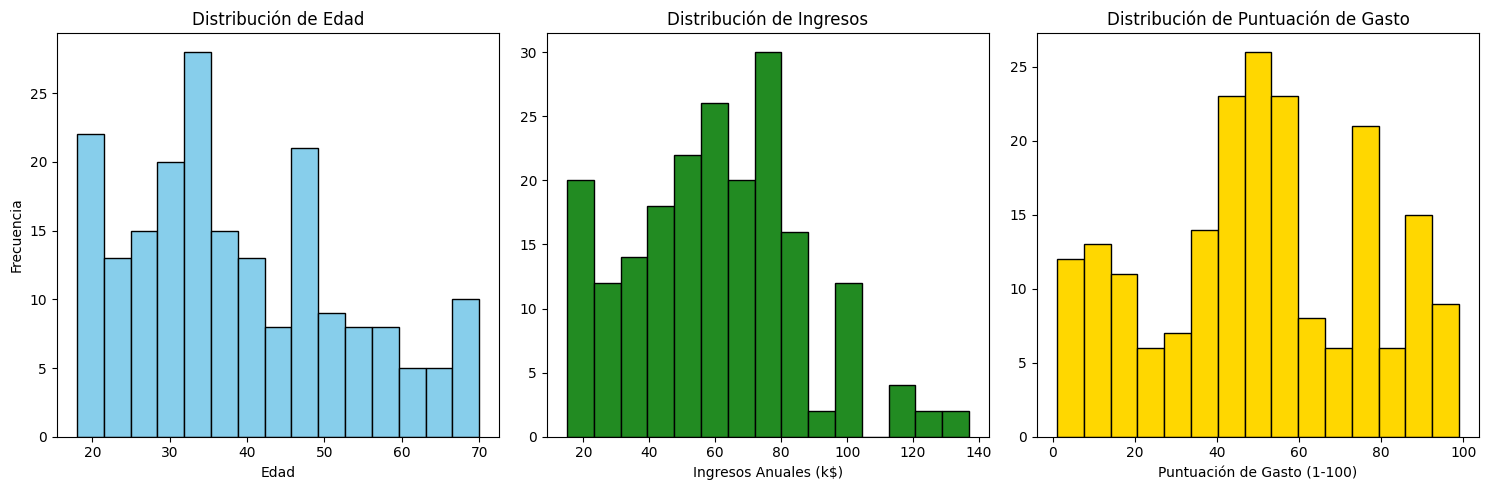

In [ ]:
from sklearn.preprocessing import StandardScaler

plt.figure(figsize=(15, 5))

# Histograma de Edad
plt.subplot(1, 3, 1)
plt.hist(df_clustering['Age'], bins=15, color='skyblue', edgecolor='black')
plt.title('Distribución de Edad')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')

# Histograma de Ingresos Anuales
plt.subplot(1, 3, 2)
plt.hist(df_clustering['Annual Income (k$)'], bins=15, color='forestgreen', edgecolor='black')
plt.title('Distribución de Ingresos')
plt.xlabel('Ingresos Anuales (k$)')

# Histograma de Puntuación de Gasto
plt.subplot(1, 3, 3)
plt.hist(df_clustering['Spending Score (1-100)'], bins=15, color='gold', edgecolor='black')
plt.title('Distribución de Puntuación de Gasto')
plt.xlabel('Puntuación de Gasto (1-100)')

plt.tight_layout()
plt.show()

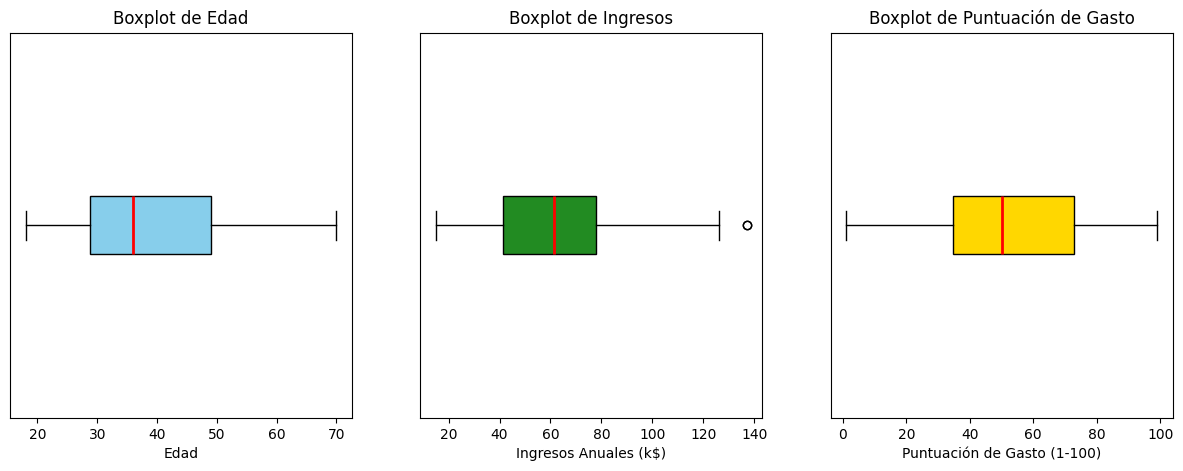

In [ ]:
plt.figure(figsize=(15, 5))

# Boxplot de Edad
plt.subplot(1, 3, 1)
plt.boxplot(df_clustering['Age'], vert=False, patch_artist=True,
                   boxprops=dict(facecolor='skyblue', color='black'),
                   medianprops=dict(color='red', linewidth=2))
plt.title('Boxplot de Edad')
plt.yticks([])
plt.xlabel('Edad')

# Boxplot de Ingresos Anuales
plt.subplot(1, 3, 2)
plt.boxplot(df_clustering['Annual Income (k$)'], vert=False, patch_artist=True,
                   boxprops=dict(facecolor='forestgreen', color='black'),
                   medianprops=dict(color='red', linewidth=2))
plt.title('Boxplot de Ingresos')
plt.yticks([])
plt.xlabel('Ingresos Anuales (k$)')

# Boxplot de Puntuación de Gasto
plt.subplot(1, 3, 3)
plt.boxplot(df_clustering['Spending Score (1-100)'], vert=False, patch_artist=True,
                   boxprops=dict(facecolor='gold', color='black'),
                   medianprops=dict(color='red', linewidth=2))
plt.title('Boxplot de Puntuación de Gasto')
plt.yticks([])
plt.xlabel('Puntuación de Gasto (1-100)')

plt.show()

Vemos que no hay muchos valores outliers.

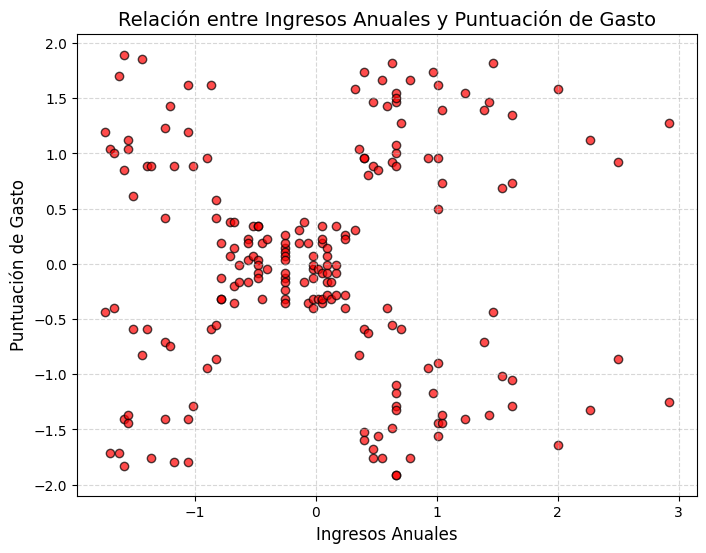

In [ ]:
# Selección de variables para entrenamiento (Ingresos y Gasto)
X = df_clustering[['Annual Income (k$)', 'Spending Score (1-100)']]

# Escalado de datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Visualizamos el resultado
plt.figure(figsize=(8, 6))

plt.scatter(X_scaled[:, 0], X_scaled[:, 1],
            color='red',
            alpha=0.7,
            edgecolors='black')

plt.title('Relación entre Ingresos Anuales y Puntuación de Gasto', fontsize=14)
plt.xlabel('Ingresos Anuales', fontsize=12)
plt.ylabel('Puntuación de Gasto', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

Se puede apreciar con esta selección de variables que hay (visualmente) 5 grupos bastante diferenciados. Veamos si coincide con lo que obtenemos con el algoritmo.

### 1.2.2. Algoritmo K-Means
Experimentaremos con varios números de clusters para hallar el mejor resultado según la regla del codo

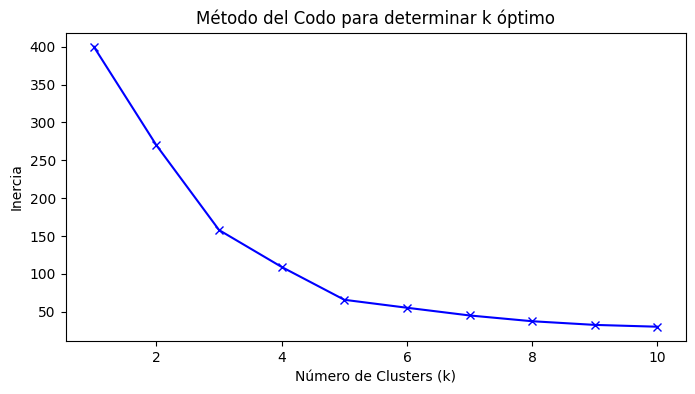

In [ ]:
from sklearn.cluster import KMeans

inercia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inercia.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inercia, 'bx-')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo para determinar k óptimo')
plt.show()

Observando esta gráfica vemos que, al igual que veíamos en la gráfica anterior, el número de clústers debe ser $k=5$. Entrenemos al modelo con este $k$.

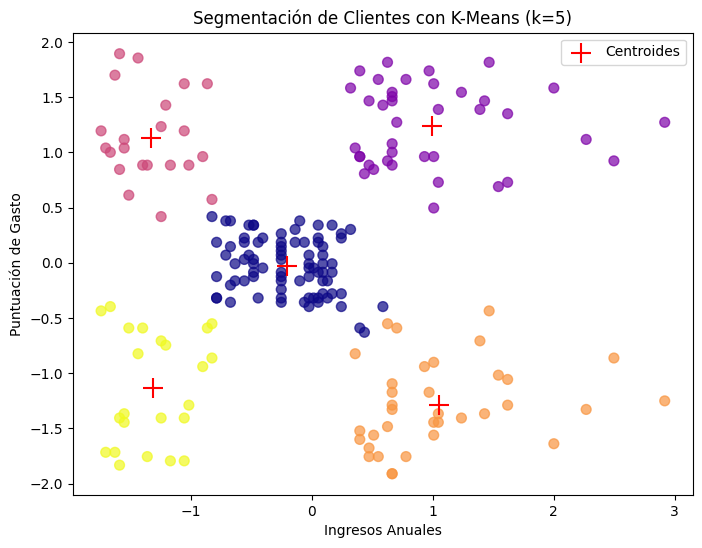

In [ ]:
# Entrenamiento
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters_kmeans = kmeans_final.fit_predict(X_scaled)

# Visualización
plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters_kmeans, cmap='plasma', s=50, alpha=0.7)
centroids = kmeans_final.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='+', label='Centroides')

plt.title('Segmentación de Clientes con K-Means (k=5)')
plt.xlabel('Ingresos Anuales')
plt.ylabel('Puntuación de Gasto')
plt.legend()
plt.show()

Vemos que visualmente parece bastante acertado.

### 1.2.3. Algoritmo Jerárquico (Aglomerativo) o DBSCAN

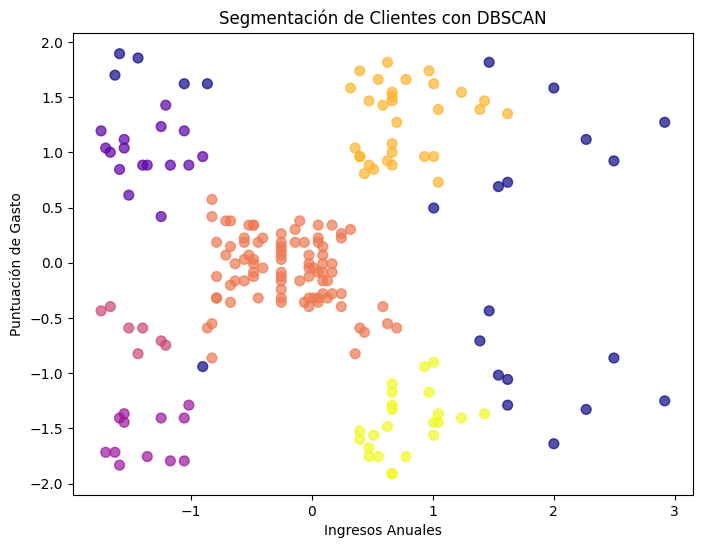

In [26]:
from sklearn.cluster import DBSCAN

# Ajuste de hiperparámetros
# eps: distancia máxima entre dos muestras para que se consideren vecinas
# min_samples: número mínimo de muestras en un vecindario para que un punto sea central
dbscan = DBSCAN(eps=0.35, min_samples=5)
clusters_dbscan = dbscan.fit_predict(X_scaled)

# Visualización
plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters_dbscan, cmap='plasma', s=50, alpha=0.7)
plt.title('Segmentación de Clientes con DBSCAN')
plt.xlabel('Ingresos Anuales')
plt.ylabel('Puntuación de Gasto')
plt.show()

Vemos que ofrece resultados muy parecidos a k-Means, pero este algoritmo detecta 6 clústers (mientras que k-Means lo entrenamos para 5) y además deja bastantes puntos sin grupo (los que aparecen en azul, outliers). Parece visualmente que k-means ofrece mejores resultados.

### 1.2.4. Interpretación
Basándonos en los resultados de K-Means ($k=5$), podemos identificar los siguientes perfiles de clientes (indicando el color correspondiente en el gráfico de k-means):

1. **Grupo "Ahorradores"** (Altos ingresos, bajo gasto): Clientes que tienen un alto poder adquisitivo pero que no gastan mucho en el centro comercial. (Color naranja)

2. **Grupo "Clientes estrella"** (Altos ingresos, alto gasto): Clientes que tienen dinero y deciden gastarlo en este centro comercial. (Color morado)

3. **Grupo "Promedio"** (Ingresos medios, gasto medio): El grupo más numeroso. Se comportan de forma equilibrada. (Color azul)

4. **Grupo "Derrochadores"** (Bajos ingresos, alto gasto): Clientes que a pesar de no tener muchos ingresos gastan mucho dinero en los comercios. (Color rosa)

5. **Grupo "Precavidos"** (Bajos ingresos, bajo gasto): Clientes con poco presupuesto que gastan poco. (Color amarillo)




## **Conclusiones Generales**

Añada una celda de texto final reflexionando sobre la utilidad de los distintos parámetros, así como los resultados obtenidos.

### Utilidad de los parámetros utilizados

- **K-Means y la elección de $k$**: El Método del Codo resultó ser una herramienta visual muy clara y efectiva para definir la estructura del modelo. Coincidía con lo que visualmente se podía intuir al representar los puntos una vez estadarizado los datos.

- **DBSCAN (`eps` y `min_samples`):** Este algoritmo nos dio una aproximación totalmente distinta basada en densidad. Aunque requirió un ajuste manual más fino de sus hiperparámetros (donde el radio `eps` determina el alcance del vecindario y `min_samples` el umbral para ser un punto central, ajustados para obtener los mejores resultados), su capacidad intrínseca para ignorar el ruido (outliers) es una gran ventaja técnica frente a K-Means, que fuerza a todos los puntos a pertenecer a un grupo. Aún así, el último grupo resultaron valores outliers (el color azul no representaba un clúster visual).

### Resultados obtenidos

En este caso, K-Means resultó ser el mejor modelo para agrupar a estaos clientes. Al estar los datos distribuidos en grupos tan definidos y con forma circular, K-Means logró segmentar a toda la base de clientes de una manera clara y que coincide con lo que se podría haber hecho sin ningún algoritmo (por los grupos visuales).

---

# **Ejercicio 2: Reglas de Asociación (5 puntos)**

## 2.1 Contexto: Análisis de la Cesta de la Compra (Market Basket)

Un supermercado desea optimizar la disposición de sus productos en los estantes. Para ello, quiere descubrir patrones de compra conjunta entre sus clientes.

**Objetivo:** Extraer reglas de asociación (tipo "Si compra X, entonces compra Y") utilizando el algoritmo **Apriori**.

**Datos:** El dataset contiene transacciones de un supermercado durante 30 días. Cada fila representa los productos comprados por un cliente en una visita.

In [18]:
# Carga de datos Asociación (Groceries)
# Dataset con formato: member_id, item_date, item_description
url = 'https://drive.google.com/file/d/1_4DM5wEaGnZY07bXRPzHTwszXHCXhcaP/view?usp=sharing'
url='https://drive.google.com/uc?id=' + url.split('/')[-2]
df_rules = pd.read_fwf(url, sep=',', header=None)

# Nota: Este dataset en particular viene en un formato donde cada fila tiene items variables.
# Para facilitar la carga inicial, mostramos las primeras filas crudas.
print("Datos de Transacciones cargados:")
display(df_rules.head())

Datos de Transacciones cargados:


,0
0,"citrus fruit,semi-finished bread,margarine,rea..."
1,"tropical fruit,yogurt,coffee"
2,whole milk
3,"pip fruit,yogurt,cream cheese ,meat spreads"
4,"other vegetables,whole milk,condensed milk,lon..."


## 2.2 Tareas de Análisis y Minería de Reglas

1.  **Preprocesado de Transacciones:**
    * Los datos deben transformarse a un formato adecuado para el algoritmo Apriori (una lista de listas de transacciones o una matriz One-Hot/Sparse).
    * Utilice `TransactionEncoder` de la librería `mlxtend` o funciones similares de manipulación de pandas.

2.  **Generación de Itemsets Frecuentes:**
    * Aplique algoritmos para encontrar conjuntos de productos frecuentes.
    * Fije un umbral de **Soporte (Support)** mínimo (empiece con un valor bajo, ej: 0.01 o 0.02) y justifique su elección.

3.  **Extracción de Reglas:**
    * Genere las reglas de asociación a partir de los itemsets.
    * Filtre las reglas por una métrica de calidad, preferiblemente **Lift** (Elevación) o **Confianza (Confidence)**.

4. **Comparación entre algoritmos:**
    * La solución debe utilizar al menos dos algoritmos entre los existentes en la biblioteca `mlxtend`.

4.  **Análisis de Resultados:**
    * Muestre las 5 reglas con mayor *Lift*.
    * Interprete una de las reglas obtenidas en lenguaje natural. ¿Tiene sentido comercial?

### 2.2.1. Preprocesado de Transacciones

Transformaremos los datos al formato matriz One-Hot.

In [19]:
# !pip install mlxtend

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

transactions = []
for index, row in df_rules.iterrows():
    # Eliminamos valores nulos y separamos por comas
    row_string = str(row.values[0])
    item_list = [item.strip() for item in row_string.split(',') if item.strip() != 'nan' and item.strip() != 'None']
    if item_list:
        transactions.append(item_list)

# Usamos TransactionEncoder para transformar a matriz booleana (One-Hot)
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_trans = pd.DataFrame(te_ary, columns=te.columns_)

print(f"Dimensiones de la matriz One-Hot: {df_trans.shape}")
display(df_trans.head())

Dimensiones de la matriz One-Hot: (9835, 398)


,,Instant f,Instant fo,Instant food,Instant food produ,Instant food products,UHT-milk,abrasi,abrasive cleaner,artif. sweetener,...,whipped/sour cream,whisky,whit,white,white b,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


### 2.2.2. Generación de Itemsets frecuentes

Utilizaremos los algoritmos A priori y FP-Growth, de la librería `mlxtend`. Fijamos `min_sup` a $0.01$ para tener un conjunto representativo de itemsets, ya que con $0.02$ obtenemos $114$ que no está mal pero podemos estar perdiendo información. Con un umbral más alto ya somos demasiado restrictivos (con $0.03$ obtenemos 59 itemsets) mientras que con uno más bajo tarda demasiado en calcularlo, además de poder producir mucho ruido (con $0.05$ obtenemos 817 itemsets que son demasiados).

In [20]:
import time # para comparar la eficiencia (ya que dan los mismos resultados)

min_sup = 0.01 # Umbral de soporte mínimo
# 0.005 -> 817 itemsets
# 0.01  -> 285 itemsets
# 0.02  -> 114 itemsets
# 0.03  ->  59 itemsets

# Algoritmo 1: Apriori
start_time_ap = time.time()
frequent_itemsets_ap = apriori(df_trans, min_support=min_sup, use_colnames=True)
time_ap = time.time() - start_time_ap

# Algoritmo 2: FP-Growth
start_time_fp = time.time()
frequent_itemsets_fp = fpgrowth(df_trans, min_support=min_sup, use_colnames=True)
time_fp = time.time() - start_time_fp

# Comprobamos que ambos algoritmos encontraron la misma cantidad total de itemsets
print(f"Total itemsets Apriori: {len(frequent_itemsets_ap)}")
print(f"Total itemsets FP-Growth: {len(frequent_itemsets_fp)}")

# Ordenamos ambos de mayor a menor soporte para comparar cabeceras
ap_sorted = frequent_itemsets_ap.sort_values(by='support', ascending=False)
fp_sorted = frequent_itemsets_fp.sort_values(by='support', ascending=False)

print(f"\nA priori ({time_ap:.4f}s):")
display(ap_sorted.head())

print(f"\nFP-Growth ({time_fp:.4f}s):")
display(fp_sorted.head())

Total itemsets Apriori: 285
Total itemsets FP-Growth: 285

A priori (0.3508s):


,support,itemsets
81,0.255516,(whole milk)
51,0.193493,(other vegetables)
61,0.182308,(rolls/buns)
70,0.170107,(soda)
82,0.139502,(yogurt)



FP-Growth (6.5784s):


,support,itemsets
6,0.255516,(whole milk)
9,0.193493,(other vegetables)
13,0.182308,(rolls/buns)
24,0.170107,(soda)
3,0.139502,(yogurt)


### 2.2.3. Extracción de reglas

Como obtenemos exactamente los mismos itemsets con ambos algoritmos usaremos los de `Apriori` (se han conseguido de forma mucho más rápida). Usamos un filtro de lift con mínimo $1.2$, lo cual indica aquellos productos que tienen más de un 20\% de posibilidades de comprarse después de otro producto (un margen suficientemente bueno para considerarlo relevante).

In [21]:
# Ejemplo alternativo filtrando por un Lift mayor a 1.2
rules = association_rules(frequent_itemsets_ap, metric="lift", min_threshold=1.2)

### 2.2.4. Comparación entre algoritmos

Ambos algoritmos nos dan el mismo resultado por lo que no podemos compararlos en cuanto a efectividad. Sin embargo, la diferencia de tiempo sí es muy notable entre ambos algoritmos. Para ver esta diferencia de forma más notable veamos la siguiente tabla y gráfica:


Tabla de resultados:


,min_sup,Tiempo Apriori (s),Tiempo FP-Growth (s)
0,0.0500,0.0531,0.6215
1,0.0400,0.0826,1.3947
2,0.0300,0.1139,3.3600
3,0.0200,0.5184,2.9564
4,0.0100,0.3351,6.6169
5,0.0075,0.6065,12.3762
6,0.0050,1.3126,24.6520


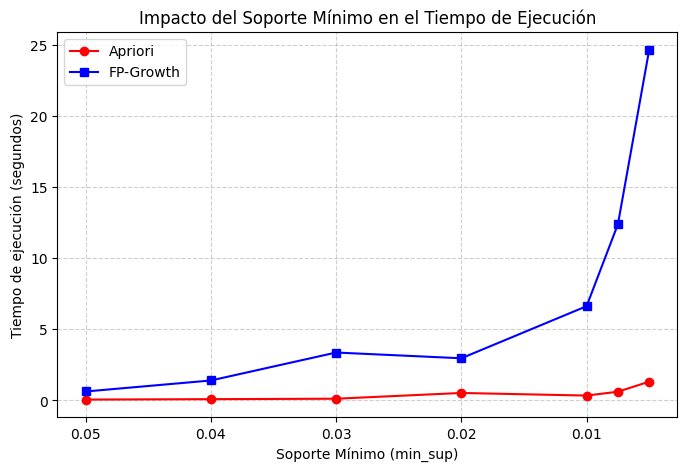

In [23]:
valores_soporte = [0.05, 0.04, 0.03, 0.02, 0.01, 0.0075, 0.005]

# Lista para guardar los resultados
tiempos_comparativa = []

for sup in valores_soporte:
  # A priori
  inicio_ap = time.time()
  apriori(df_trans, min_support=sup, use_colnames=True)
  fin_ap = time.time()
  tiempo_apriori = fin_ap - inicio_ap

  # FP-Growth
  inicio_fp = time.time()
  fpgrowth(df_trans, min_support=sup, use_colnames=True)
  fin_fp = time.time()
  tiempo_fpgrowth = fin_fp - inicio_fp

  # Guardamos los datos en la lista
  tiempos_comparativa.append({
      'min_sup': sup,
      'Tiempo Apriori (s)': round(tiempo_apriori, 4),
      'Tiempo FP-Growth (s)': round(tiempo_fpgrowth, 4)
  })

# Convertimos la lista de diccionarios en un DataFrame para visualizarlo como tabla
df_tiempos = pd.DataFrame(tiempos_comparativa)

print("\nTabla de resultados:")
display(df_tiempos)

# Gráfica
plt.figure(figsize=(8, 5))
plt.plot(df_tiempos['min_sup'], df_tiempos['Tiempo Apriori (s)'], marker='o', label='Apriori', color='red')
plt.plot(df_tiempos['min_sup'], df_tiempos['Tiempo FP-Growth (s)'], marker='s', label='FP-Growth', color='blue')
plt.gca().invert_xaxis() # Invertimos el eje X para que el soporte vaya de mayor a menor
plt.title('Impacto del Soporte Mínimo en el Tiempo de Ejecución')
plt.xlabel('Soporte Mínimo (min_sup)')
plt.ylabel('Tiempo de ejecución (segundos)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Podemos ver que para valores de `min_sup` muy pequeños, el algoritmo `FP-Growth` es mucho peor (tarda muchísimo más, como se puede apreciar en la gráfica). Como proporciona los mismos resultados, este va a ser el único criterio que utilicemos para decir que `Apriori` es bastante mejor (al no crear estructuras tan complejas es más eficiente).

### 2.2.5. Análisis de resultados

In [25]:
# Extraemos las 5 reglas con mayor lift
top_5_rules = rules.sort_values(by='lift', ascending=False).head(5)
display(top_5_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])
print("\n\n")

,antecedents,consequents,support,confidence,lift
298,(curd),"(yogurt, whole milk)",0.010066,0.188931,3.372304
295,"(yogurt, whole milk)",(curd),0.010066,0.179673,3.372304
281,(root vegetables),"(other vegetables, citrus fruit)",0.010371,0.095149,3.295045
276,"(other vegetables, citrus fruit)",(root vegetables),0.010371,0.359155,3.295045
341,(root vegetables),"(other vegetables, tropical fruit)",0.012303,0.112873,3.144780


Podemos hacer la siguiente interpretación de la regla 276:
- Si un cliente compra verduras en general (_other vegetables_) y frutas cítricas (_citrus fruit_), entonces es muy probable que compre también verduras de raíz (_root vegetables_).

Podemos analizar además que tiene un soporte del 1.03\%, es decir, que esta regla se dio en el 1.03\% del total de todas las ventas del supermercado durante los 30 días estudiados (un valor considerablemente alto).

Además tiene una confianza del 35.9\%, es decir, que la probabilidad de que añada las verduras de raíz después de los otros productos es de un 35.9\% (más de un tercio de las personas que compran otras verduras y frutas cítricas compran también las de raíz).

Finalmente vemos que tiene un lift de 3.29, es decir, la probabilidad de que alguien compre verduras de raíz es casi 3.3 veces mayor si ya lleva verduras y cítricos, en comparación con otro cliente cualquiera (podemos descartar que sea coincidencia).

---

## **Conclusiones Generales**

Añada una celda de texto final reflexionando sobre la utilidad de los distintos parámetros, así como los resultados obtenidos.

### Utilidad de los parámetros utilizados

El parámetro `min_suport` ha sido el primer filtro de relevancia. Durante el análisis, se observó que un soporte del 1% (0.01) es un punto de equilibrio adecuado para este dataset (cantidad de reglas estudiadas en relación con el tiempo).

Anteriormente se ha estudiado ya la relevancia de este parámetro pero podemos afirmar como conclusión que un valor medio nos da resultados suficientemente relevantes sin introducir mucho ruido en el estudio.

### Resultados obtenidos

Los resultados obtenidos revelan patrones de consumo que además tienen lógica en el mundo real. Hemos obtenido principalmente las 5 siguientes:

- Si un cliente compra cuajada, entonces también añade yogur y leche entera con una probabilidad del 18.89\%.

- Si un cliente compra yogur y leche entera, entonces también añade cuajada con una probabilidad del 17.97\%.

- Si un cliente compra verduras de raíz, entonces también añade otras verduras y frutas cítricas con una probabilidad del 9.51\%.

- Si un cliente compra otras verduras y frutas cítricas, entonces también añade verduras de raíz con una probabilidad del 35.92\%.

- Si un cliente compra verduras de raíz, entonces también añade otras verduras y frutas tropicales con una probabilidad del 11.29\%.

Esto nos dice que la gente que va a comprar lácteos suele seguir comprando este tipo de productos y al igual con las verduras.

Descrubrir esto permite al supermercado pasar de una disposición de estantes intuitiva a una basada en estos datos, además de poder ofrecer promociones para favorecer aún más este tipo de conductas, poder predecirlas y aprovecharlo en su favor.